In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import yaml
import pandas as pd
import os
from pathlib import Path

In [9]:
LOG_FOLDER = Path("../logs/")

## Convergence Comparison

In [114]:
# Load results
def load_deeppso_iteration_results(log_folder):
    avg_iteration_files = list(Path(log_folder).rglob("avg_gbest_cost_iterations.csv"))
    assert len(avg_iteration_files) > 0, "No avg_gbest_cost_iterations.csv file found in logs"
    iteration_result = pd.read_csv(avg_iteration_files[0]).to_numpy()[0, 1:].astype(float)
    iteration_result = np.concatenate((iteration_result, np.ones_like(iteration_result) * iteration_result[-1]))  # Prepend initial cost for iteration 0
    return iteration_result

dp_20_iter = load_deeppso_iteration_results(LOG_FOLDER / "tsp" / "nc20")
dp_50_iter = load_deeppso_iteration_results(LOG_FOLDER / "tsp" / "nc50")
dp_100_iter = load_deeppso_iteration_results(LOG_FOLDER / "tsp" / "nc100")
dp_200_iter = load_deeppso_iteration_results(LOG_FOLDER / "tsp" / "nc200")
dp_500_iter = load_deeppso_iteration_results(LOG_FOLDER / "tsp" / "nc500")

In [121]:
traditional_results = pd.read_csv(LOG_FOLDER / "viz" / "traditional_pso_trajectory.csv").to_numpy()[:, 1:].astype(float)
trd_20_iter, trd_50_iter, trd_100_iter, trd_200_iter, trd_500_iter = traditional_results

swap_results = pd.read_csv(LOG_FOLDER / "viz" / "swap_pso_trajectory.csv").to_numpy()[:, 1:].astype(float)
sp_20_iter, sp_50_iter, sp_100_iter, sp_200_iter, sp_500_iter = swap_results

adaptive_results = pd.read_csv(LOG_FOLDER / "viz" / "adaptive_pso_trajectory.csv").to_numpy()[:, 1:].astype(float)
adp_20_iter, adp_50_iter, adp_100_iter, adp_200_iter, adp_500_iter = adaptive_results

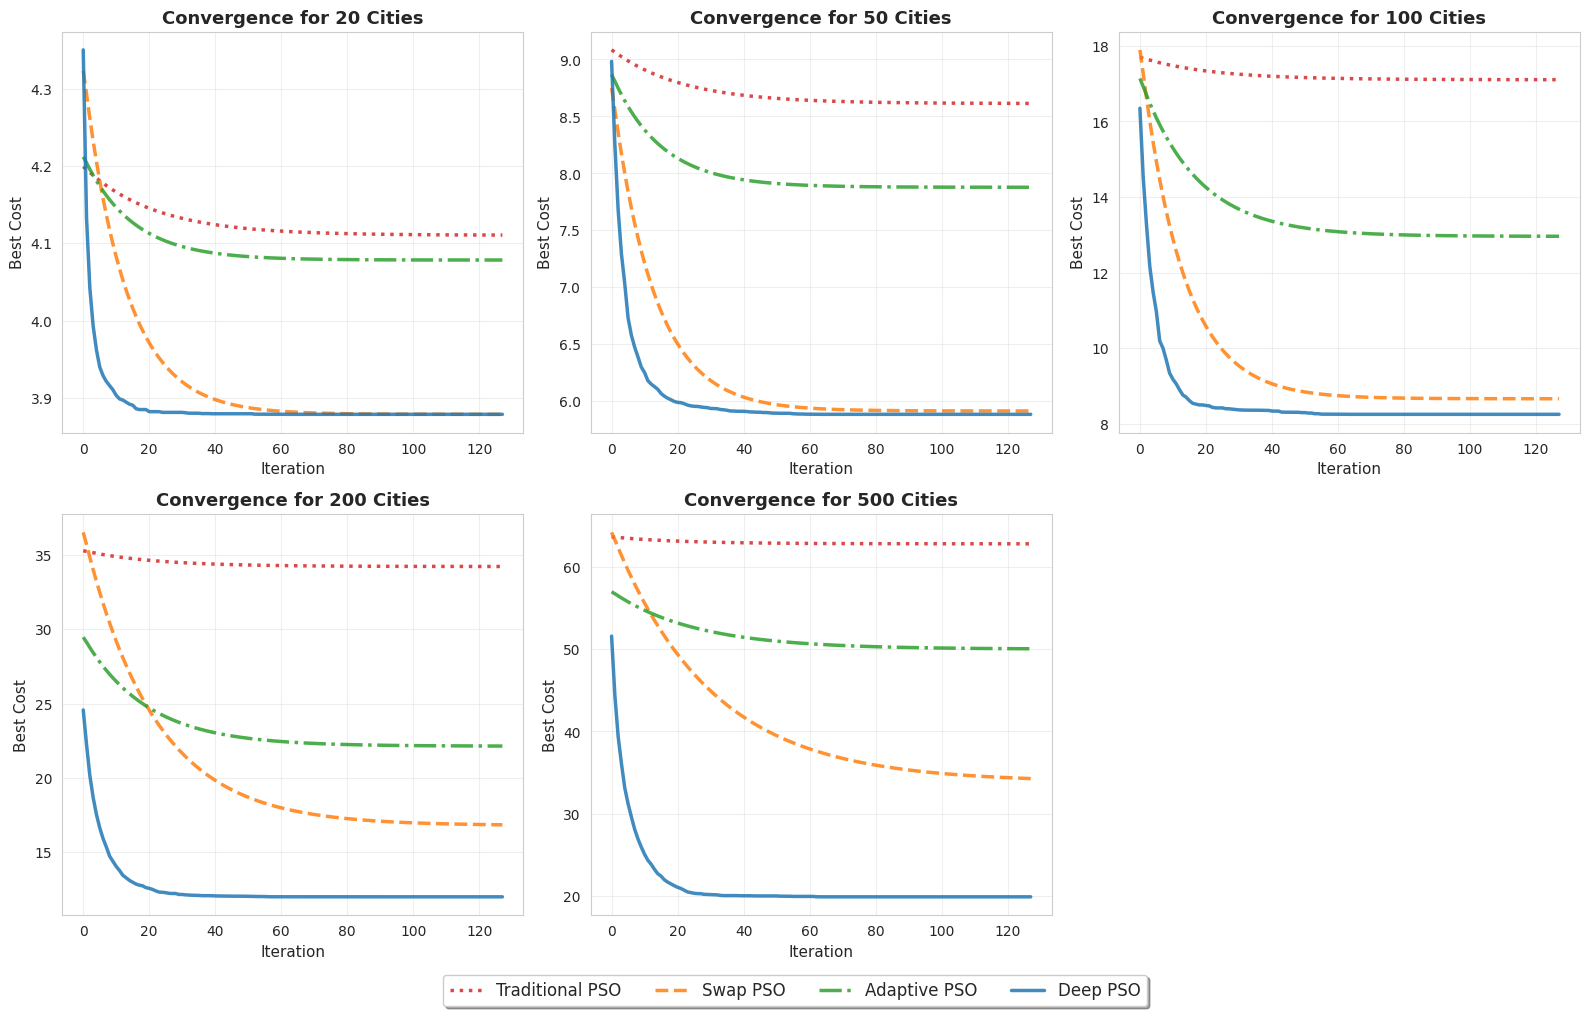

In [130]:
# Plot the convergence of each method across different city counts with improved styling
def plot_convergence(city_counts, pso_iters, swap_iters, adaptive_iters, deeppso_iters):
    sns.set_style("whitegrid")
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    # Define consistent colors and styles for all algorithms
    colors = {
        "Traditional PSO": "#d62728",  # blue
        "Swap PSO": "#ff7f0e",          # orange
        "Adaptive PSO": "#2ca02c",      # green
        "Deep PSO": "#1f77b4"           # red
    }
    
    linestyles = {
        "Traditional PSO": ":",
        "Swap PSO": "--",
        "Adaptive PSO": "-.",
        "Deep PSO": "-"
    }
    
    for i, city_count in enumerate(city_counts):
        ax = axes[i]
        
        # Plot all algorithms
        ax.plot(pso_iters[i], label="Traditional PSO", color=colors["Traditional PSO"], 
                linestyle=linestyles["Traditional PSO"], linewidth=2.5, alpha=0.85)
        ax.plot(swap_iters[i], label="Swap PSO", color=colors["Swap PSO"], 
                linestyle=linestyles["Swap PSO"], linewidth=2.5, alpha=0.85)
        ax.plot(adaptive_iters[i], label="Adaptive PSO", color=colors["Adaptive PSO"], 
                linestyle=linestyles["Adaptive PSO"], linewidth=2.5, alpha=0.85)
        ax.plot(deeppso_iters[i], label="Deep PSO", color=colors["Deep PSO"], 
                linestyle=linestyles["Deep PSO"], linewidth=2.5, alpha=0.85)
        
        ax.set_title(f"Convergence for {city_count} Cities", fontsize=13, fontweight='bold')
        ax.set_xlabel("Iteration", fontsize=11)
        ax.set_ylabel("Best Cost", fontsize=11)
        ax.grid(True, alpha=0.3)
    
    # Hide the last subplot
    axes[5].axis('off')
    
    # Create a single legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12, 
               bbox_to_anchor=(0.5, -0.02), frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0.02, 1, 1])
    plt.show()


plot_convergence(
    city_counts=[20, 50, 100, 200, 500],
    pso_iters=[trd_20_iter, trd_50_iter, trd_100_iter, trd_200_iter, trd_500_iter],
    swap_iters=[sp_20_iter, sp_50_iter, sp_100_iter, sp_200_iter, sp_500_iter],
    adaptive_iters=[adp_20_iter, adp_50_iter, adp_100_iter, adp_200_iter, adp_500_iter],
    deeppso_iters=[dp_20_iter, dp_50_iter, dp_100_iter, dp_200_iter, dp_500_iter],
)

## Generalization plots

In [205]:
def read_gene_plot(folder):
    file_path = Path(folder) / "metrics.csv"
    data = pd.read_csv(file_path)
    columns = data.columns
    val_wc1c2_ls_cols = [col for col in columns if col.startswith("val_wc1c2_ls")]
    col_results = {}
    for col in val_wc1c2_ls_cols:
        col_key = int(col.split("/")[-1].split("_")[0])
        col_value = data[col].dropna().to_numpy()
        col_results[col_key] = col_value
    epoch_col = data[["epoch", val_wc1c2_ls_cols[0]]].dropna().to_numpy()[:, 0].astype(int)
    col_results["epoch"] = epoch_col
    return col_results

def plot_generalization(gen_results, title_prefix, min_values_dict, filename_prefix):
    """
    Plot generalization performance on separate subplots with professional formatting.
    Automatically adapts to 1-5 evaluation datasets.
    
    Parameters:
    -----------
    gen_results : dict
        Dictionary containing epoch and validation data for different city counts
        Expected keys: 'epoch' and city_counts (e.g., 20, 50, 100, 150, 200)
    title_prefix : str
        Prefix for the figure title (e.g., "Training on 20-50 Cities")
    filename_prefix : str
        Prefix for saved files (e.g., "generalization_20_50")
    """
    sns.set_style("whitegrid")
    
    # Extract epoch and validation metrics
    epochs = gen_results.get("epoch", [])
    
    # Get all city counts (excluding 'epoch')
    city_counts = sorted([k for k in gen_results.keys() if k != "epoch"])
    num_datasets = len(city_counts)
    
    # Validate number of datasets
    if num_datasets > 5 or num_datasets < 1:
        print(f"Error: Expected 1-5 datasets, but got {num_datasets}")
        return
    
    # Use uniform styling for separate subplots (most formal/academic)
    color_palette = ["#1f77b4"] * 5  # Standard professional deep blue
    linestyle_palette = ["-"] * 5     # Uniform solid lines
    
    colors = {city_counts[i]: color_palette[i] for i in range(num_datasets)}
    linestyles = {city_counts[i]: linestyle_palette[i] for i in range(num_datasets)}
    
    # Determine subplot layout (1-5 datasets)
    if num_datasets <= 3:
        fig, axes = plt.subplots(1, num_datasets, figsize=(6*num_datasets, 6))
    elif num_datasets == 4:
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    else:  # num_datasets == 5
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Flatten axes to make indexing easier
    if num_datasets == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot validation curves for each city count in separate subplots
    for idx, city_count in enumerate(city_counts):
        ax = axes[idx]
        val_data = gen_results.get(city_count, [])
        
        if len(val_data) > 0:
            ax.plot(epochs, val_data, linewidth=2.5, color=colors[city_count], 
                    linestyle=linestyles[city_count], alpha=0.85, marker='o',
                    markersize=5, markevery=max(1, len(epochs)//18))
            min_val_epochs = min_values_dict.get(str(city_count), None)
            if min_val_epochs is not None:
                # Plot the same training curve with lighter color
                ax.plot(epochs, min_val_epochs, linewidth=2.5, color=colors[city_count], 
                        linestyle=linestyles[city_count], alpha=0.3, marker='o',
                        markersize=5, markevery=max(1, len(epochs)//18))

            # Styling for each subplot
            ax.set_xlabel('Epoch Number', fontsize=11, fontweight='semibold')
            ax.set_ylabel('Best Cost (Lower is Better)', fontsize=11, fontweight='semibold')
            ax.set_title(f'Validation on {city_count} Cities', fontsize=12, fontweight='bold', pad=12)
            
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
            
            # Improve spines
            for spine in ax.spines.values():
                spine.set_linewidth(1.2)
                spine.set_color('black')

    
    # Hide extra subplots if using 2x3 grid (only 1 extra when num_datasets==5)
    if num_datasets == 5:
        axes[5].axis('off')
    
    # Add overall title with professional formatting
    fig.suptitle(f'Generalization Performance: {title_prefix}, Evaluating on Different Dataset Sizes', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    # plt.savefig(f'../plots/{filename_prefix}.pdf', dpi=300, bbox_inches='tight', format='pdf')
    # plt.savefig(f'../plots/{filename_prefix}.png', dpi=300, bbox_inches='tight', format='png')
    plt.show()
    
    # Print detailed statistics
    print(f"Generalization Results ({title_prefix})")
    print(f"{'='*80}")
    stats_header = f"{'City Count':<15} {'Best Cost':<15} {'Best Epoch':<15} {'Final Cost':<15} {'Improvement':<15}"
    print(stats_header)
    print("-" * 80)
    
    for city_count in city_counts:
        val_data = gen_results.get(city_count, [])
        if len(val_data) > 0:
            min_val = np.min(val_data)
            min_epoch = epochs[np.argmin(val_data)]
            final_val = val_data[-1]
            improvement = ((final_val - min_val) / min_val * 100) if min_val != 0 else 0
            print(f"{city_count:<15} {min_val:<15.6f} {min_epoch:<15} {final_val:<15.6f} {improvement:<15.2f}%")
    
    print(f"\nFigures saved:")
    print(f"  - ../plots/{filename_prefix}.pdf")
    print(f"  - ../plots/{filename_prefix}.png")

### TSP

In [206]:
min_val_tsp = {
    "20": pd.read_csv(LOG_FOLDER / "tsp" / "nc20" / "metrics.csv")["val_wc1c2_ls/20_file"].dropna(),
    "50": pd.read_csv(LOG_FOLDER / "tsp" / "nc50" / "metrics.csv")["val_wc1c2_ls/50_random"].dropna(),
    "100": pd.read_csv(LOG_FOLDER / "tsp" / "nc100" / "metrics.csv")["val_wc1c2_ls/100_file"].dropna(),
    "200": pd.read_csv(LOG_FOLDER / "tsp" / "nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna(),
    "500": pd.read_csv(LOG_FOLDER / "tsp" / "nc500" / "metrics.csv")["val_wc1c2_ls/500_file"].dropna(),
}

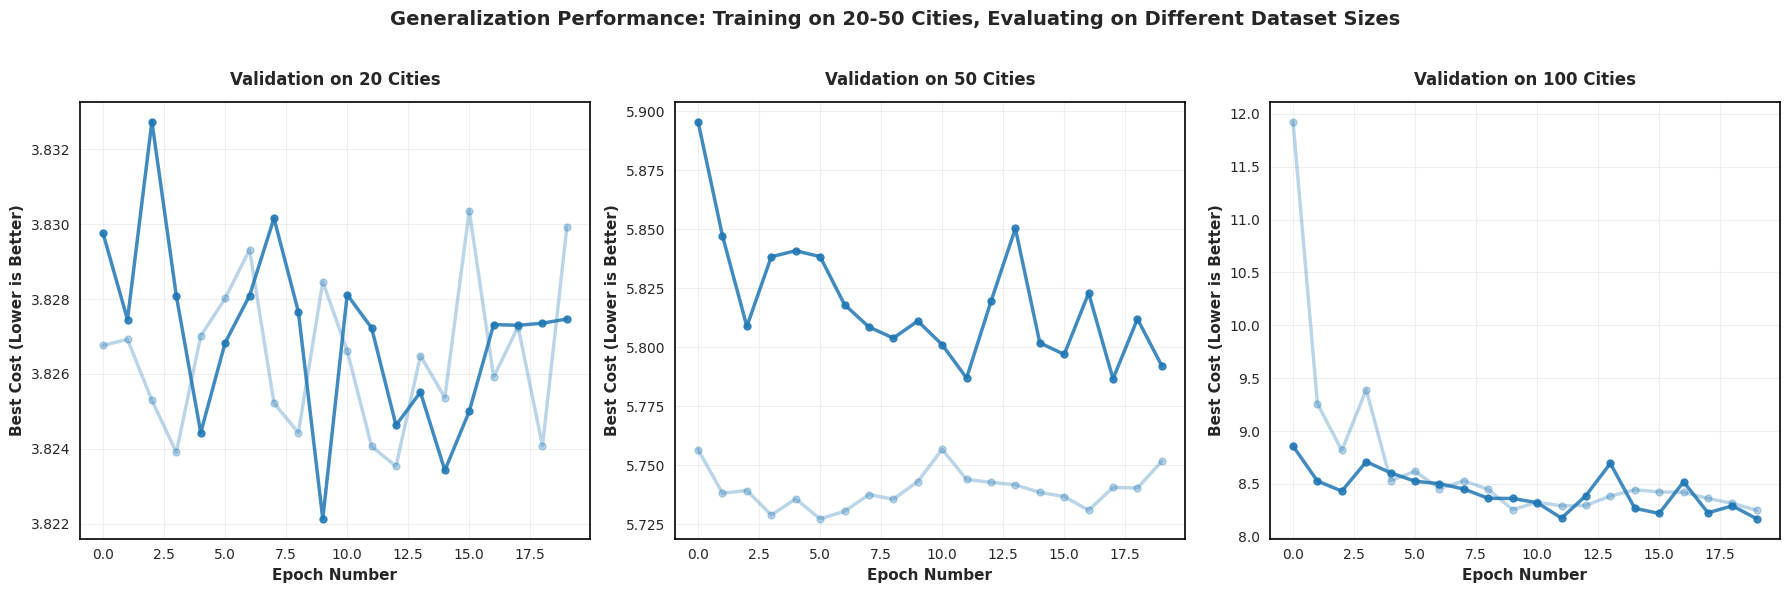

Generalization Results (Training on 20-50 Cities)
City Count      Best Cost       Best Epoch      Final Cost      Improvement    
--------------------------------------------------------------------------------
20              3.822133        9               3.827469        0.14           %
50              5.786571        17              5.792071        0.10           %
100             8.169547        19              8.169547        0.00           %

Figures saved:
  - ../plots/generalization_20_50_separated.pdf
  - ../plots/generalization_20_50_separated.png


In [207]:
# Plot generalization results for 20-50 training on 20/50/100 test sets
gene_results_20_50 = read_gene_plot(LOG_FOLDER / "tsp" / "range_nc20_50")

plot_generalization(
    gen_results=gene_results_20_50,
    title_prefix="Training on 20-50 Cities",
    min_values_dict=min_val_tsp,
    filename_prefix="generalization_20_50_separated"
)

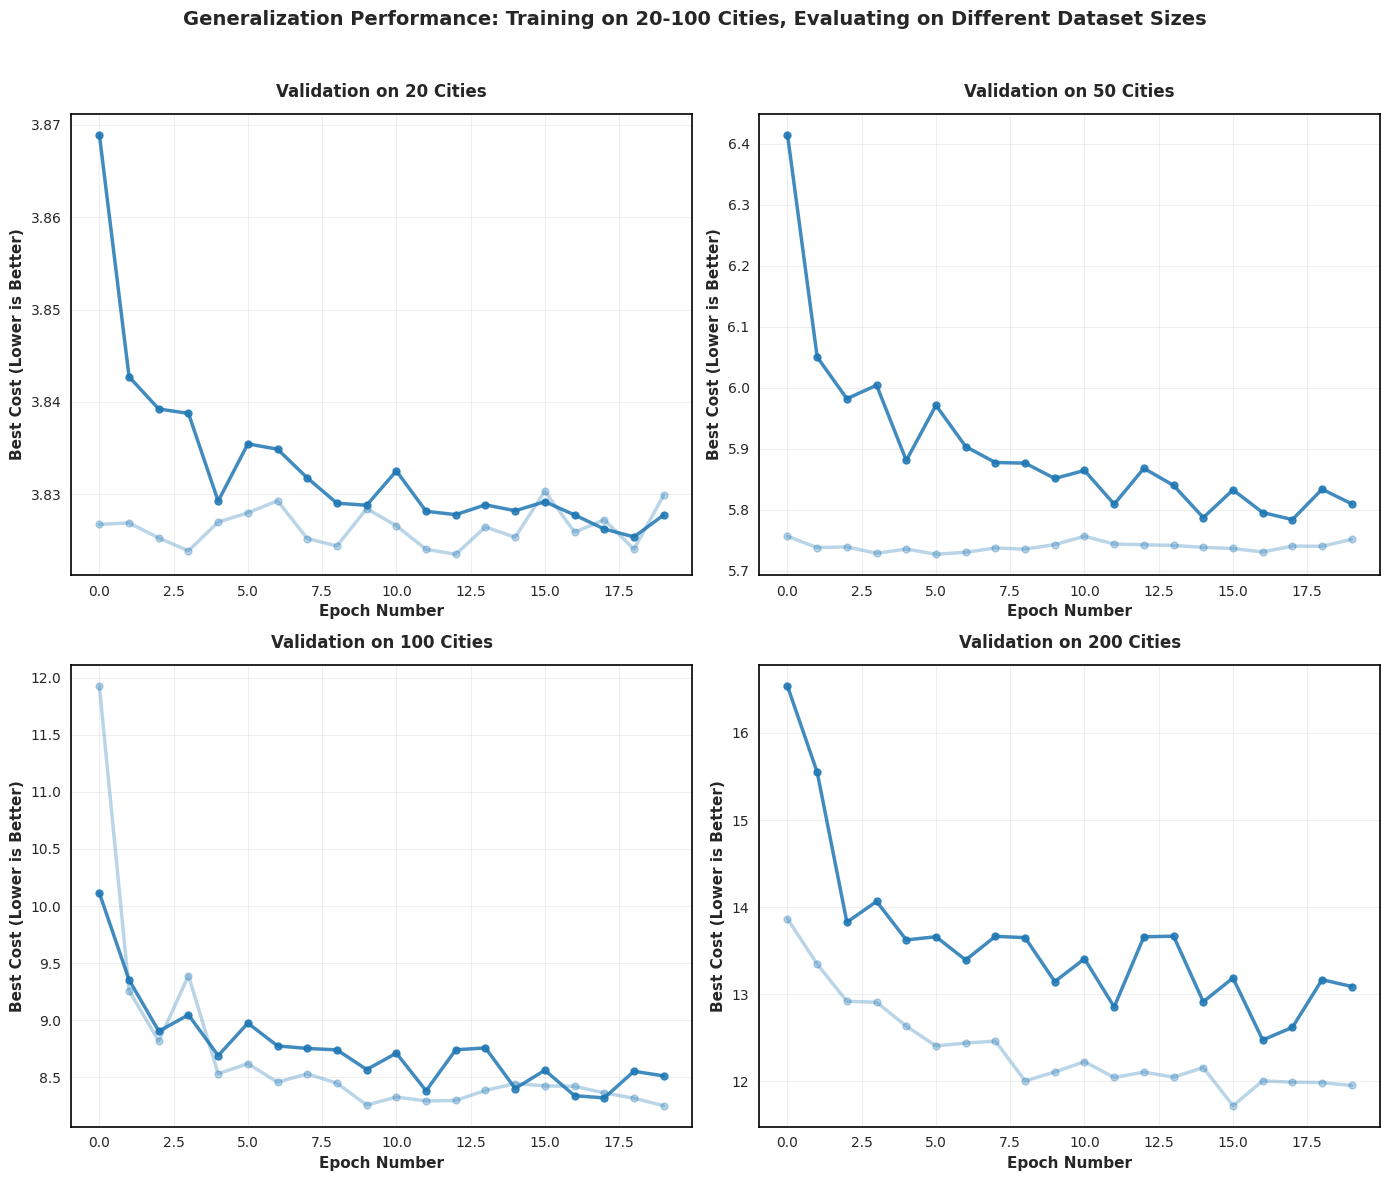

Generalization Results (Training on 20-100 Cities)
City Count      Best Cost       Best Epoch      Final Cost      Improvement    
--------------------------------------------------------------------------------
20              3.825413        18              3.827773        0.06           %
50              5.783979        17              5.809679        0.44           %
100             8.318980        17              8.511830        2.32           %
200             12.474725       16              13.088480       4.92           %

Figures saved:
  - ../plots/generalization_20_100_separated.pdf
  - ../plots/generalization_20_100_separated.png


In [208]:
gene_results_20_100 = read_gene_plot(LOG_FOLDER / "tsp" / "range_nc20_100")
# Plot generalization results for 20-100 training on 20/50/100 test sets
plot_generalization(
    gen_results=gene_results_20_100,
    title_prefix="Training on 20-100 Cities",
    min_values_dict=min_val_tsp,
    filename_prefix="generalization_20_100_separated"
)

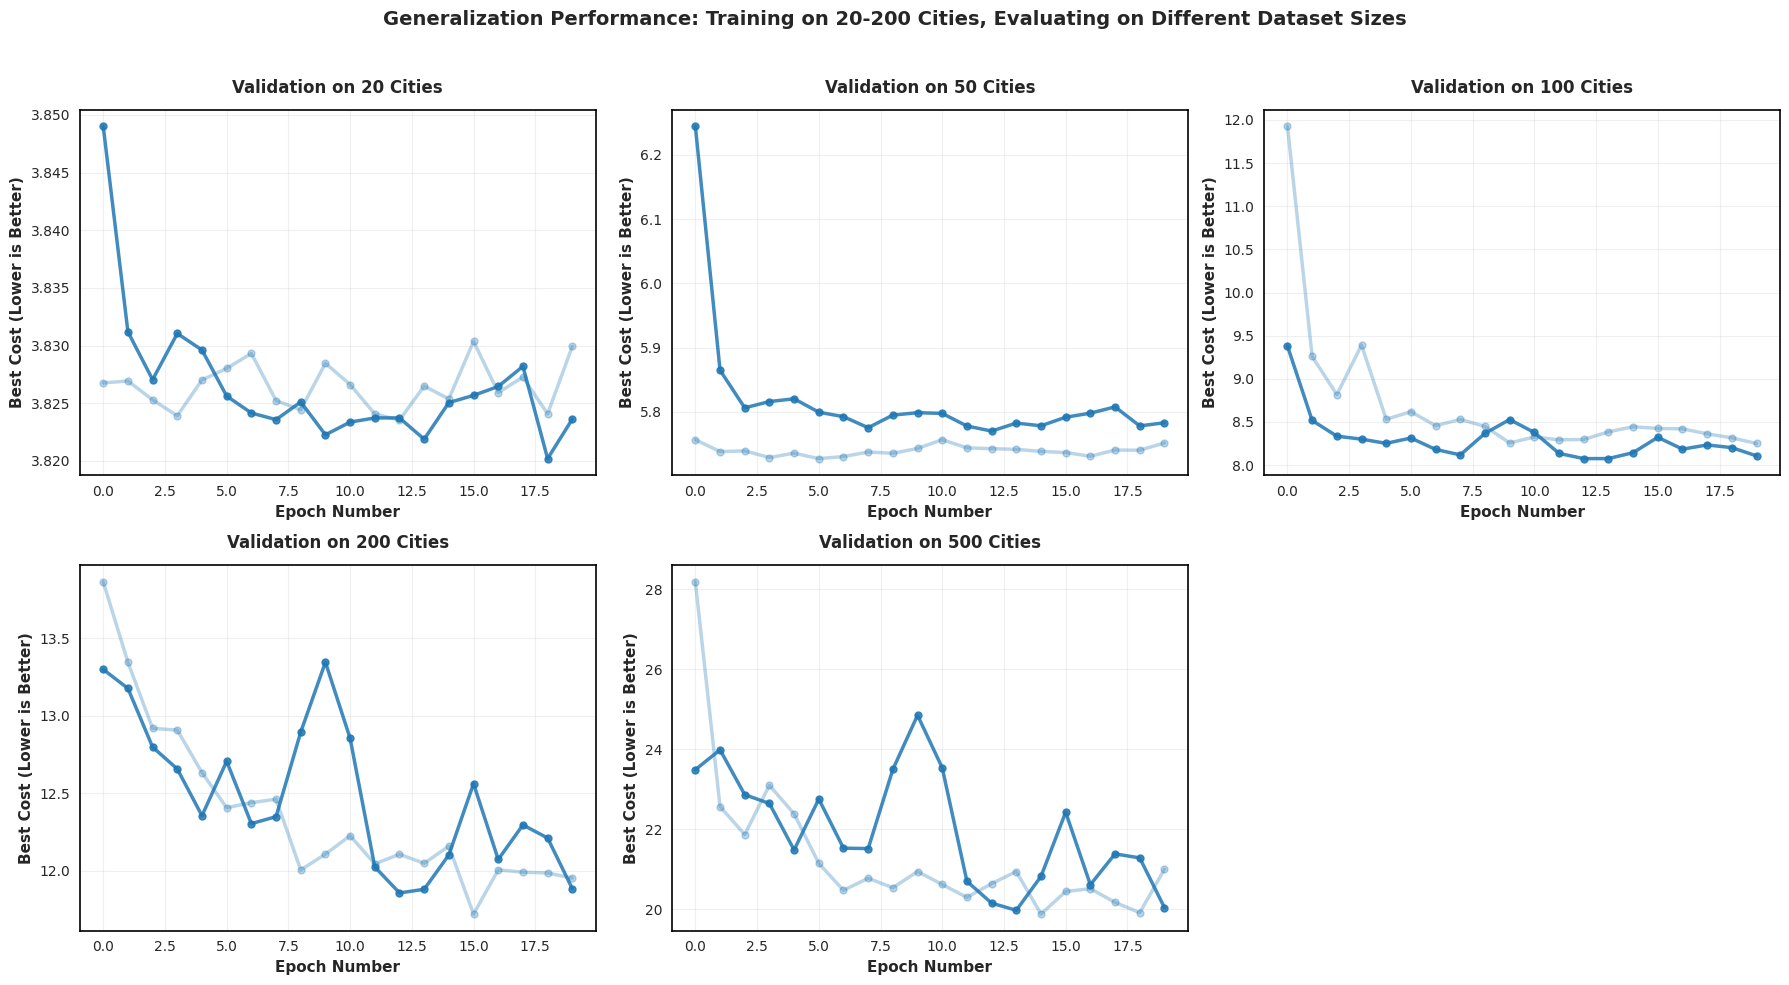

Generalization Results (Training on 20-200 Cities)
City Count      Best Cost       Best Epoch      Final Cost      Improvement    
--------------------------------------------------------------------------------
20              3.820197        18              3.823619        0.09           %
50              5.770068        12              5.782985        0.22           %
100             8.075138        12              8.106893        0.39           %
200             11.855988       12              11.883568       0.23           %
500             19.979296       13              20.049101       0.35           %

Figures saved:
  - ../plots/generalization_20_200_separated.pdf
  - ../plots/generalization_20_200_separated.png


In [209]:
gene_results_20_200 = read_gene_plot(LOG_FOLDER / "tsp" / "range_nc20_200")
# Plot generalization results for 20-200 training on 20/50/100 test sets
plot_generalization(
    gen_results=gene_results_20_200,
    title_prefix="Training on 20-200 Cities",
    min_values_dict=min_val_tsp,
    filename_prefix="generalization_20_200_separated"
)

#### Generation iteration

In [210]:
gene_iter_200, gene_iter_100 = pd.read_csv(
    "/home/parzival/projects/deeppso/logs/tsp/range_nc20_50/test_results/best-epoch=11-val_avg_cost=5.930/avg_gbest_cost_iterations.csv"
).to_numpy()[:, 1:].astype(float)


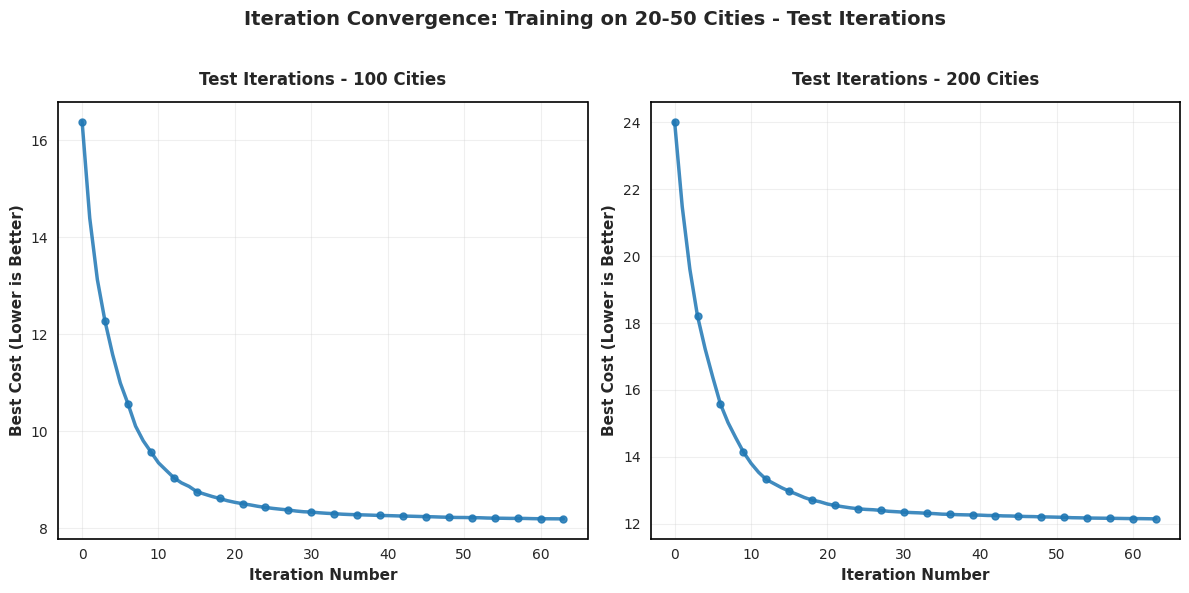


Iteration Convergence Results (Training on 20-50 Cities - Test Iterations)
City Count      Best Cost       Best Iter       Final Cost      Improvement    
--------------------------------------------------------------------------------
100             8.194860        63              8.194860        0.00           %
200             12.140365       63              12.140365       0.00           %


In [211]:
def plot_iteration_convergence(iterations_dict, title_prefix):
    """
    Plot iteration convergence performance on separate subplots with professional formatting.
    Automatically adapts to 1-5 evaluation datasets.
    
    Parameters:
    -----------
    iterations_dict : dict
        Dictionary containing iteration convergence data for different city counts
        Expected keys: city_counts (e.g., 100, 200)
        Values are numpy arrays of cost values across iterations
    title_prefix : str
        Prefix for the figure title (e.g., "Training on 20-50 Cities - Test Iterations")
    """
    sns.set_style("whitegrid")
    
    # Get all city counts and sort them
    city_counts = sorted([k for k in iterations_dict.keys()])
    num_datasets = len(city_counts)
    
    # Validate number of datasets
    if num_datasets > 5 or num_datasets < 1:
        print(f"Error: Expected 1-5 datasets, but got {num_datasets}")
        return
    
    # Use uniform styling for separate subplots (most formal/academic)
    color_palette = ["#1f77b4"] * 5  # Standard professional deep blue
    linestyle_palette = ["-"] * 5     # Uniform solid lines
    
    colors = {city_counts[i]: color_palette[i] for i in range(num_datasets)}
    linestyles = {city_counts[i]: linestyle_palette[i] for i in range(num_datasets)}
    
    # Determine subplot layout (1-5 datasets)
    if num_datasets <= 3:
        fig, axes = plt.subplots(1, num_datasets, figsize=(6*num_datasets, 6))
    elif num_datasets == 4:
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    else:  # num_datasets == 5
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Flatten axes to make indexing easier
    if num_datasets == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot convergence curves for each city count in separate subplots
    for idx, city_count in enumerate(city_counts):
        ax = axes[idx]
        iter_data = iterations_dict.get(city_count, [])
        
        if len(iter_data) > 0:
            iterations = np.arange(len(iter_data))
            ax.plot(iterations, iter_data, linewidth=2.5, color=colors[city_count], 
                    linestyle=linestyles[city_count], alpha=0.85, marker='o',
                    markersize=5, markevery=max(1, len(iter_data)//18))
            
            # Styling for each subplot
            ax.set_xlabel('Iteration Number', fontsize=11, fontweight='semibold')
            ax.set_ylabel('Best Cost (Lower is Better)', fontsize=11, fontweight='semibold')
            ax.set_title(f'Test Iterations - {city_count} Cities', fontsize=12, fontweight='bold', pad=12)
            
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
            
            # Improve spines
            for spine in ax.spines.values():
                spine.set_linewidth(1.2)
                spine.set_color('black')
    
    # Hide extra subplots if using 2x3 grid (only 1 extra when num_datasets==5)
    if num_datasets == 5:
        axes[5].axis('off')
    
    # Add overall title with professional formatting
    fig.suptitle(f'Iteration Convergence: {title_prefix}', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Print detailed statistics
    print(f"\nIteration Convergence Results ({title_prefix})")
    print(f"{'='*80}")
    stats_header = f"{'City Count':<15} {'Best Cost':<15} {'Best Iter':<15} {'Final Cost':<15} {'Improvement':<15}"
    print(stats_header)
    print("-" * 80)
    
    for city_count in city_counts:
        iter_data = iterations_dict.get(city_count, [])
        if len(iter_data) > 0:
            min_cost = np.min(iter_data)
            best_iter = np.argmin(iter_data)
            final_cost = iter_data[-1]
            improvement = ((final_cost - min_cost) / min_cost * 100) if min_cost != 0 else 0
            print(f"{city_count:<15} {min_cost:<15.6f} {best_iter:<15} {final_cost:<15.6f} {improvement:<15.2f}%")


# Plot iteration convergence for 20-50 training range
plot_iteration_convergence(
    iterations_dict={100: gene_iter_100, 200: gene_iter_200},
    title_prefix="Training on 20-50 Cities - Test Iterations"
)

### CVRP

In [212]:
min_val_cvrp = {
    "20": pd.read_csv(LOG_FOLDER / "cvrp" / "nc20" / "metrics.csv")["val_wc1c2_ls/20_file"].dropna(),
    "50": pd.read_csv(LOG_FOLDER / "cvrp" / "nc50" / "metrics.csv")["val_wc1c2_ls/50_random"].dropna(),
    "100": pd.read_csv(LOG_FOLDER / "cvrp" / "nc100" / "metrics.csv")["val_wc1c2_ls/100_file"].dropna(),
    "200": pd.read_csv(LOG_FOLDER / "cvrp" / "nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna(),
}

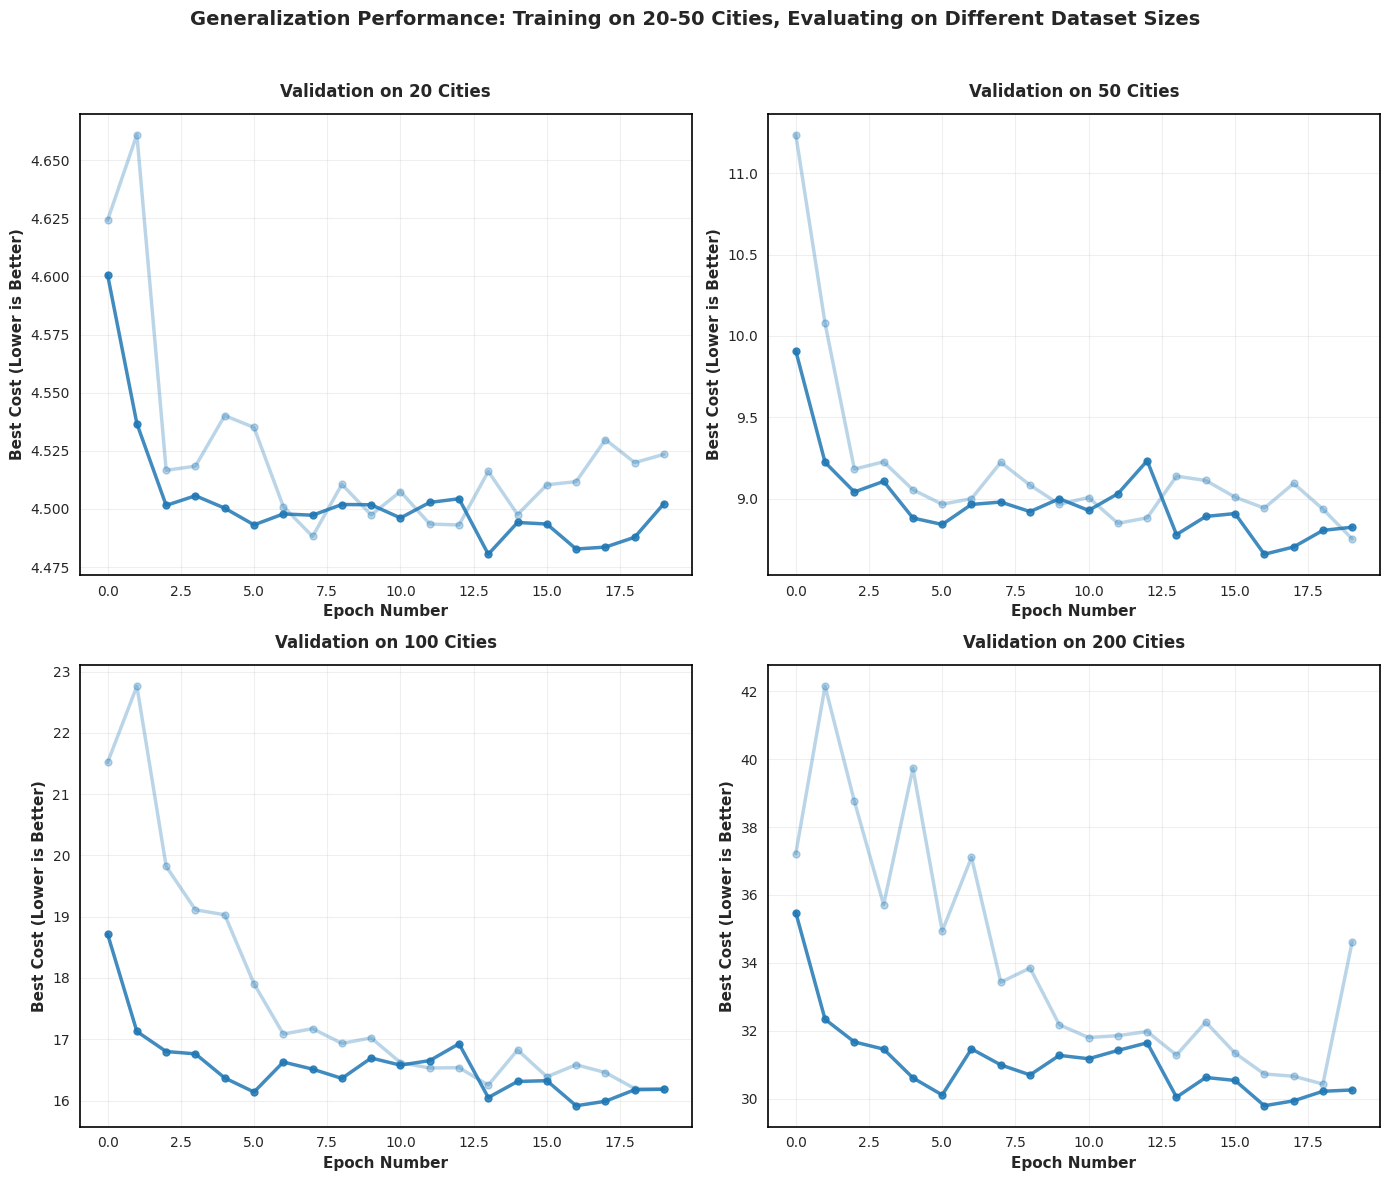

Generalization Results (Training on 20-50 Cities)
City Count      Best Cost       Best Epoch      Final Cost      Improvement    
--------------------------------------------------------------------------------
20              4.480510        13              4.502316        0.49           %
50              8.659085        16              8.825136        1.92           %
100             15.915823       16              16.184500       1.69           %
200             29.790865       16              30.255713       1.56           %

Figures saved:
  - ../plots/generalization_20_50_separated.pdf
  - ../plots/generalization_20_50_separated.png


In [213]:
# Plot generalization results for 20-50 training on 20/50/100 test sets
gene_results_20_50 = read_gene_plot(LOG_FOLDER / "cvrp" / "range_nc20_50")

plot_generalization(
    gen_results=gene_results_20_50,
    title_prefix="Training on 20-50 Cities",
    min_values_dict=min_val_cvrp,
    filename_prefix="generalization_20_50_separated"
)

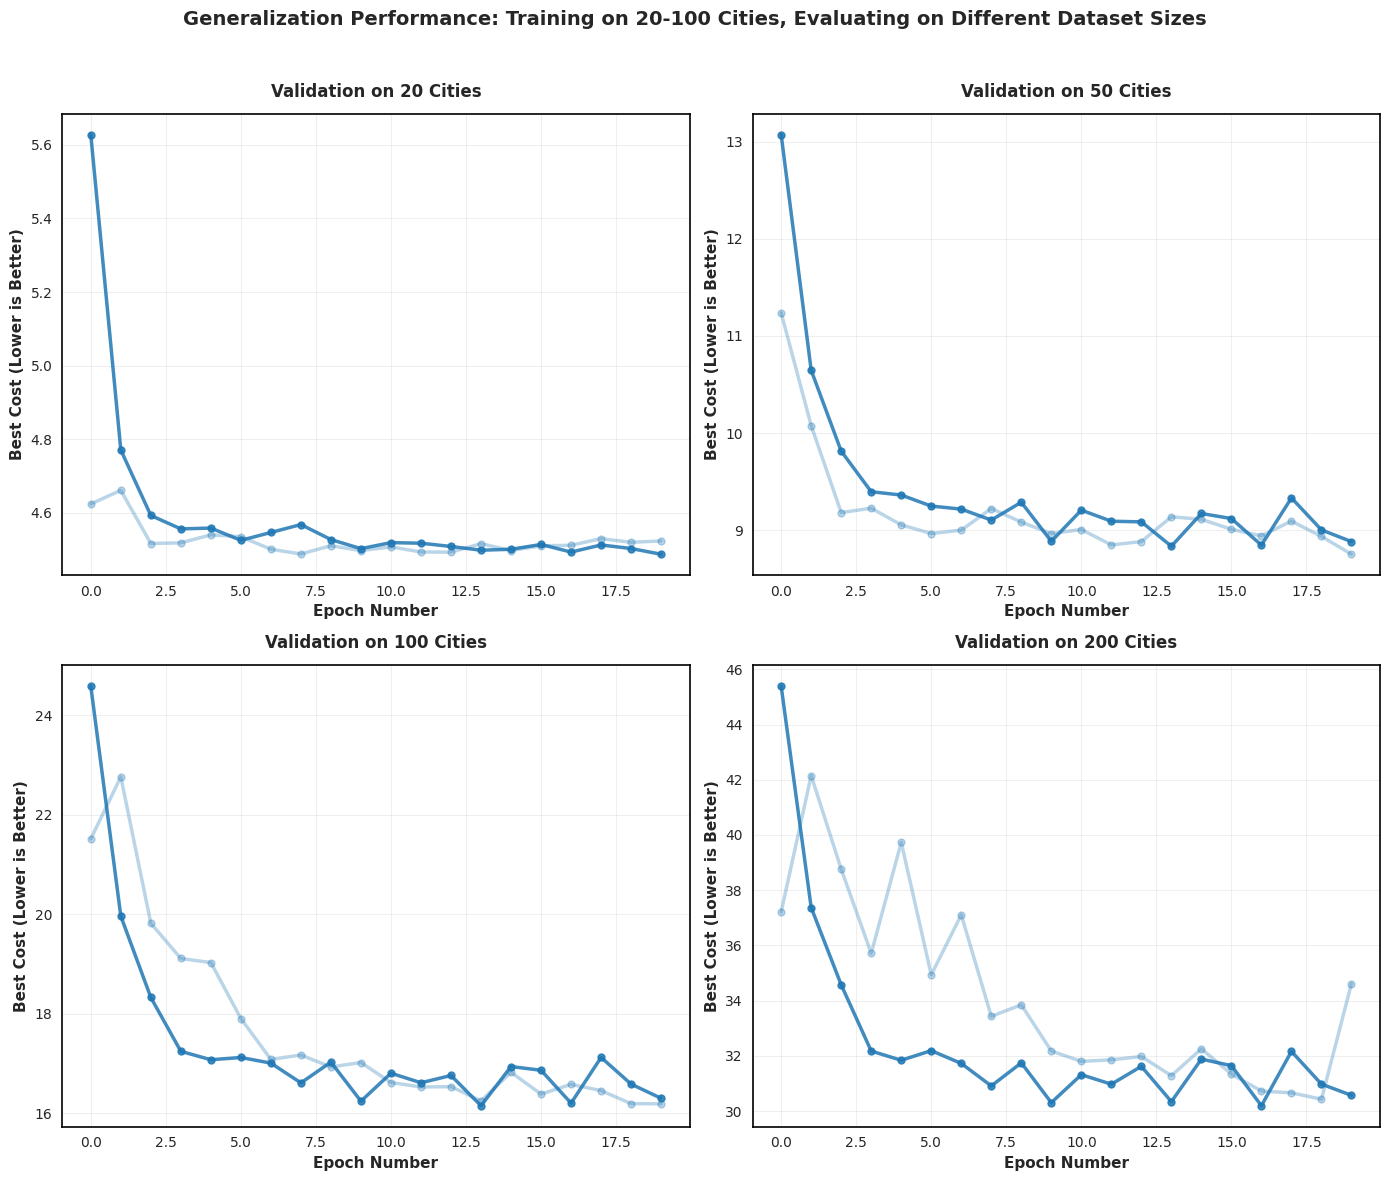

Generalization Results (Training on 20-100 Cities)
City Count      Best Cost       Best Epoch      Final Cost      Improvement    
--------------------------------------------------------------------------------
20              4.487442        19              4.487442        0.00           %
50              8.835526        13              8.882749        0.53           %
100             16.154034       13              16.303402       0.92           %
200             30.193317       16              30.570980       1.25           %

Figures saved:
  - ../plots/generalization_20_100_separated.pdf
  - ../plots/generalization_20_100_separated.png


In [214]:
gene_results_20_100 = read_gene_plot(LOG_FOLDER / "cvrp" / "range_nc20_100")
# Plot generalization results for 20-100 training on 20/50/100 test sets
plot_generalization(
    gen_results=gene_results_20_100,
    title_prefix="Training on 20-100 Cities",
    min_values_dict=min_val_cvrp,
    filename_prefix="generalization_20_100_separated"
)

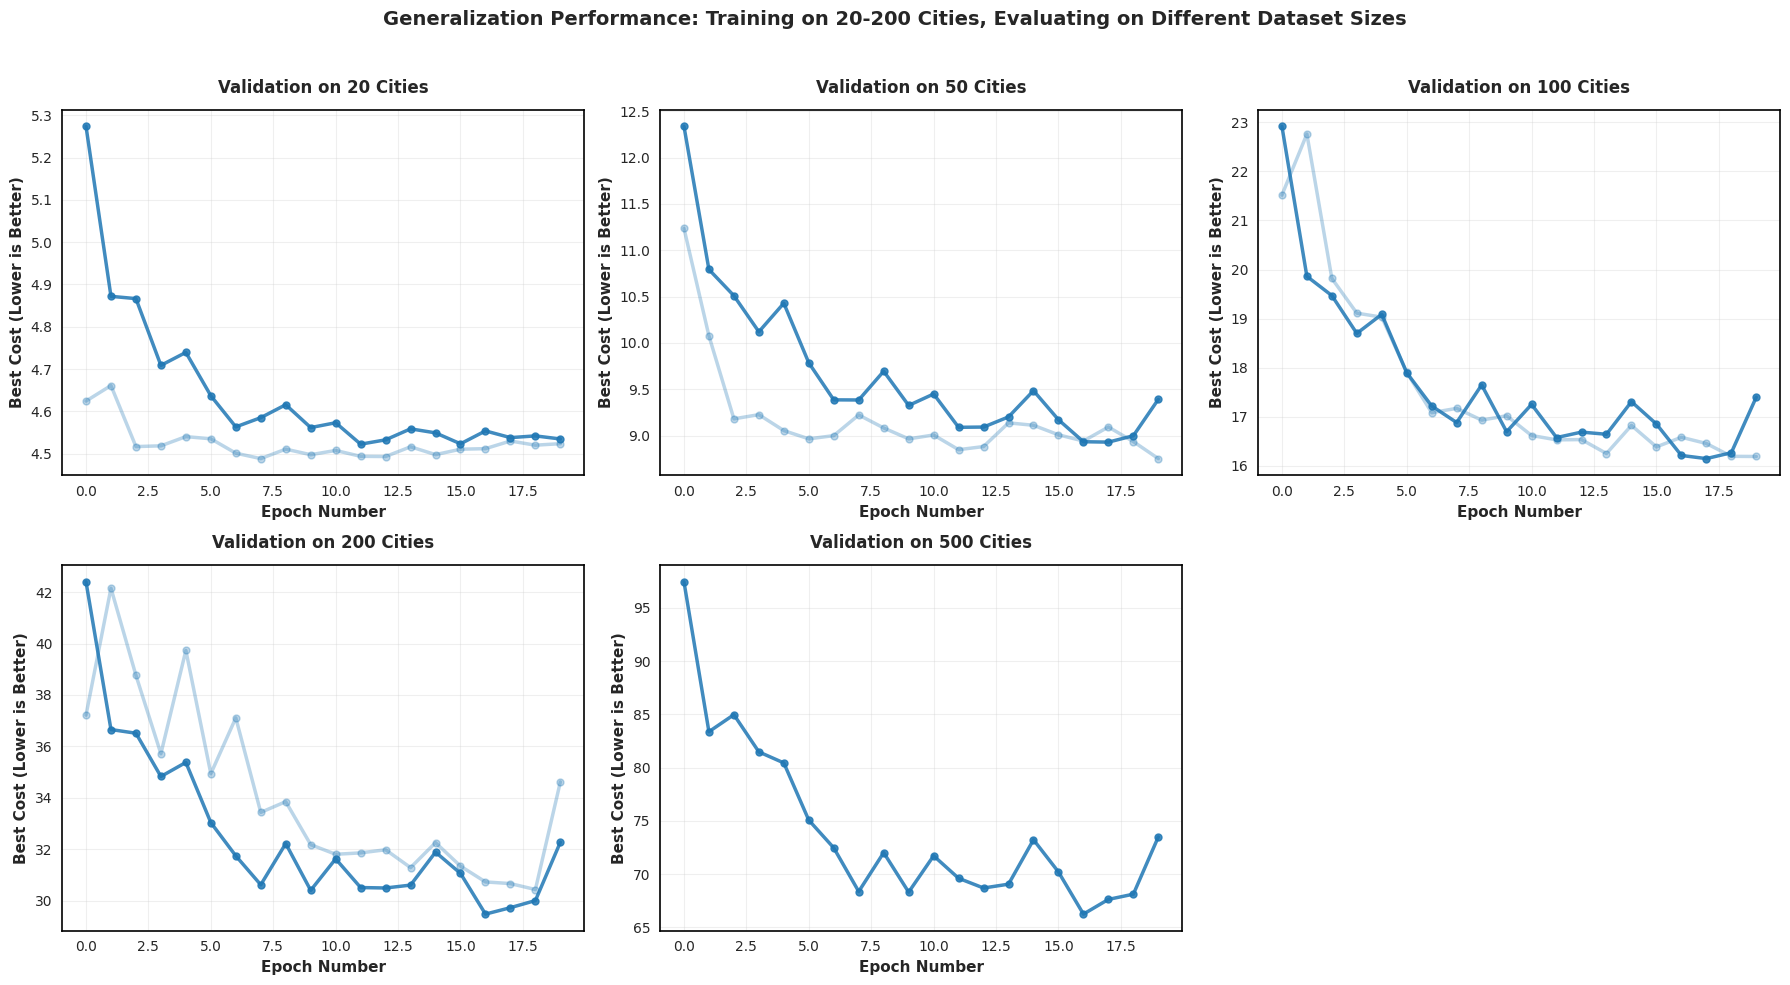

Generalization Results (Training on 20-200 Cities)
City Count      Best Cost       Best Epoch      Final Cost      Improvement    
--------------------------------------------------------------------------------
20              4.522319        11              4.534631        0.27           %
50              8.930699        17              9.392404        5.17           %
100             16.149569       17              17.402552       7.76           %
200             29.473768       16              32.271133       9.49           %
500             66.237404       16              73.489258       10.95          %

Figures saved:
  - ../plots/generalization_20_200_separated.pdf
  - ../plots/generalization_20_200_separated.png


In [215]:
gene_results_20_200 = read_gene_plot(LOG_FOLDER / "cvrp" / "range_nc20_200")
# Plot generalization results for 20-200 training on 20/50/100 test sets
plot_generalization(
    gen_results=gene_results_20_200,
    title_prefix="Training on 20-200 Cities",
    min_values_dict=min_val_cvrp,
    filename_prefix="generalization_20_200_separated"
)

## Ablation iteration-training

### TSP

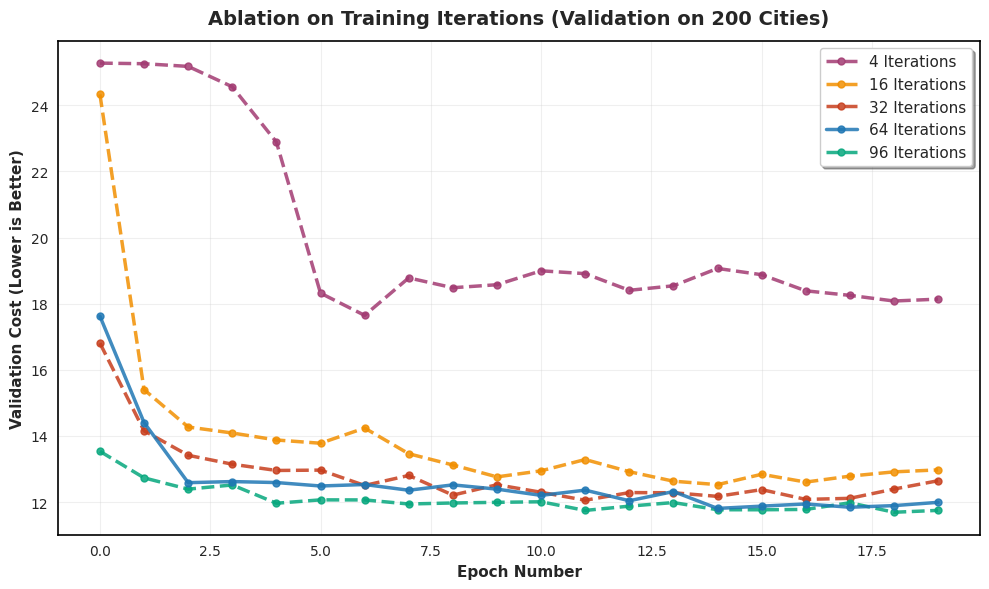

In [229]:
iteration_4 = pd.read_csv(LOG_FOLDER / "tsp" / "iter04_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
iteration_16 = pd.read_csv(LOG_FOLDER / "tsp" / "iter16_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
iteration_32 = pd.read_csv(LOG_FOLDER / "tsp" / "iter32_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
iteration_64 = pd.read_csv(LOG_FOLDER / "tsp" / "iter64_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
iteration_96 = pd.read_csv(LOG_FOLDER / "tsp" / "iter96_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()

def plot_ablation_training(ablation_dict, title, configured_value=None, label_suffix=" Iterations"):
    sns.set_style("whitegrid")
    
    # We will plot all on the same axis for comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    
    other_colors = ["#A23B72", "#F18F01", "#C73E1D", "#06A77D", "#593C8F"]
    color_idx = 0
    
    for idx, (label, data) in enumerate(ablation_dict.items()):
        epochs = np.arange(len(data))
        
        # Check if this is the configured/baseline value
        if configured_value is not None and str(label) == str(configured_value):
            color = "#1f77b4"  # Distinct blue
            linestyle = "-"     # Continuous line
            zorder = 5          # Draw on top
        else:
            color = other_colors[color_idx % len(other_colors)]
            linestyle = "--"    # Dashed line
            color_idx += 1
            zorder = 3
            
        ax.plot(epochs, data, linewidth=2.5, color=color, 
                linestyle=linestyle, alpha=0.85, marker='o',
                markersize=5, markevery=max(1, len(epochs)//18), label=f"{label}{label_suffix}", zorder=zorder)
        
    ax.set_xlabel('Epoch Number', fontsize=11, fontweight='semibold')
    ax.set_ylabel('Validation Cost (Lower is Better)', fontsize=11, fontweight='semibold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    
    # Improve spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')
        
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

plot_ablation_training(
    ablation_dict={
        4: iteration_4,
        16: iteration_16,
        32: iteration_32,
        64: iteration_64,
        96: iteration_96
    },
    title="Ablation on Training Iterations (Validation on 200 Cities)",
    configured_value=64
)

### CVRP

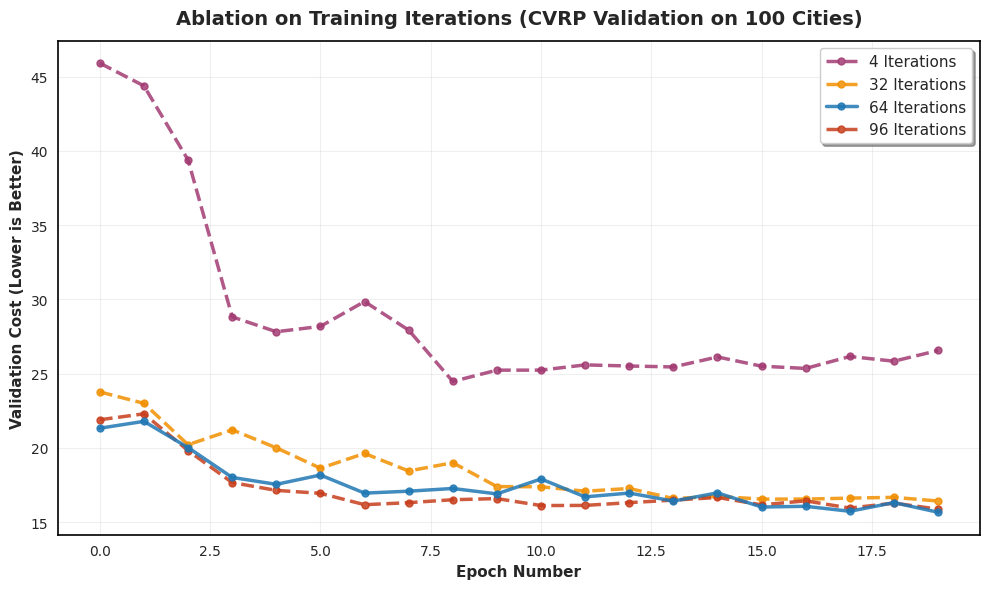

In [230]:
iteration_4 = pd.read_csv(LOG_FOLDER / "cvrp" / "iter04_nc100" / "metrics.csv")["val_wc1c2_ls/100_file"].dropna()
iteration_32 = pd.read_csv(LOG_FOLDER / "cvrp" / "iter32_nc100" / "metrics.csv")["val_wc1c2_ls/100_file"].dropna()
iteration_64 = pd.read_csv(LOG_FOLDER / "cvrp" / "iter64_nc100" / "metrics.csv")["val_wc1c2_ls/100_file"].dropna()
iteration_96 = pd.read_csv(LOG_FOLDER / "cvrp" / "iter96_nc100" / "metrics.csv")["val_wc1c2_ls/100_file"].dropna()

plot_ablation_training(
    ablation_dict={
        4: iteration_4,
        32: iteration_32,
        64: iteration_64,
        96: iteration_96
    },
    title="Ablation on Training Iterations (CVRP Validation on 100 Cities)",
    configured_value=64
)

## Ablation #particles

### TSP

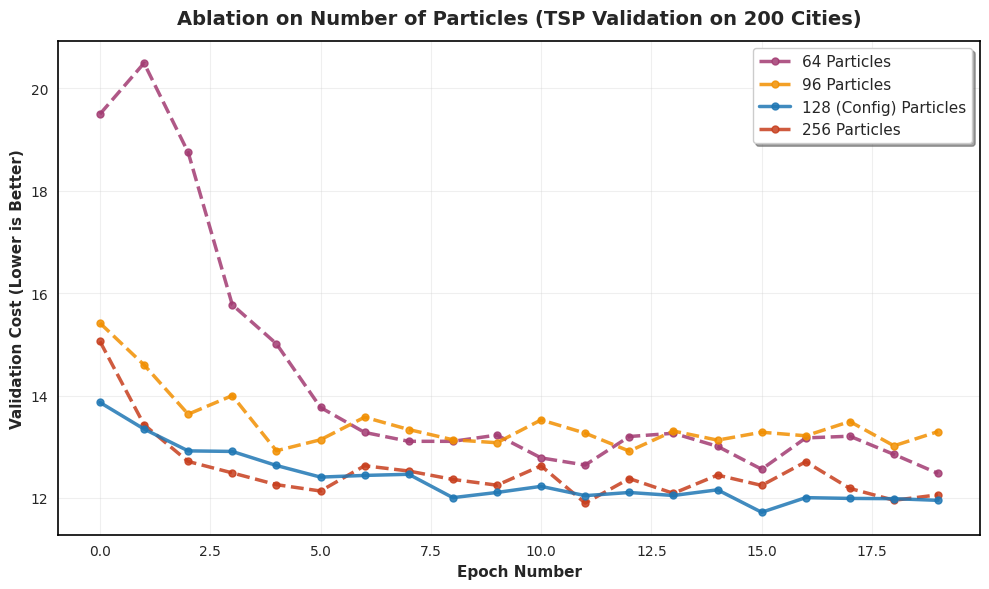

In [231]:
n_particles_64 = pd.read_csv(LOG_FOLDER / "tsp" / "n_particles_64_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
n_particles_96 = pd.read_csv(LOG_FOLDER / "tsp" / "n_particles_96_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
n_particles_configed = pd.read_csv(LOG_FOLDER / "tsp" / "nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()
n_particles_256 = pd.read_csv(LOG_FOLDER / "tsp" / "n_particles_256_nc200" / "metrics.csv")["val_wc1c2_ls/200_random"].dropna()

plot_ablation_training(
    ablation_dict={
        "64": n_particles_64,
        "96": n_particles_96,
        "128 (Config)": n_particles_configed,
        "256": n_particles_256
    },
    title="Ablation on Number of Particles (TSP Validation on 200 Cities)",
    configured_value="128 (Config)",
    label_suffix=" Particles"
)